In [1]:
import logging
from medmnist import BloodMNIST
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import cv2
import random
from tmu.models.classification.vanilla_classifier import TMClassifier
from sklearn.metrics import roc_auc_score,  average_precision_score
from sklearn.metrics import classification_report
import json 
from time import time
import os
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import roc_curve
import config
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
np.random.seed(config.RANDOM_SEED)
random.seed(config.RANDOM_SEED)

In [3]:
train_ds = BloodMNIST(split='train', download=True)
val_ds   = BloodMNIST(split='val',   download=True)
test_ds  = BloodMNIST(split='test',  download=True)


X_train_org = train_ds.imgs           # (N, 28, 28, 3)
Y_train     = train_ds.labels.flatten()
X_val_org   = val_ds.imgs
Y_val       = val_ds.labels.flatten()
X_test_org  = test_ds.imgs
Y_test      = test_ds.labels.flatten()

# Ensure standard dtypes first
X_train_org = X_train_org.astype(np.uint8)
X_val_org   = X_val_org.astype(np.uint8)
X_test_org  = X_test_org.astype(np.uint8)

X_train=X_train_org
X_val=X_val_org
X_test=X_test_org

Displaying 1 example per class:

Class 0


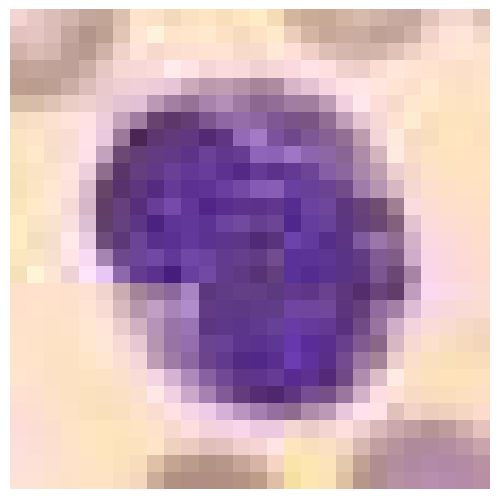

Class 1


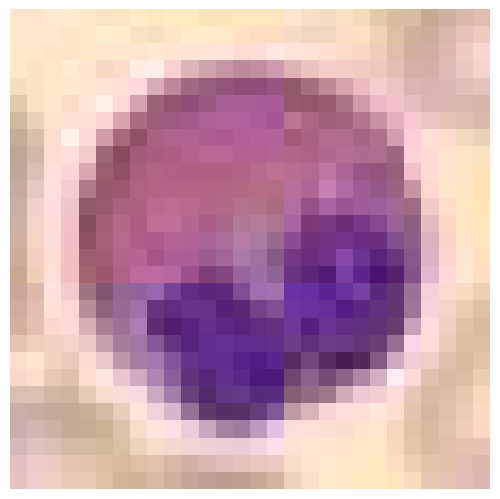

Class 2


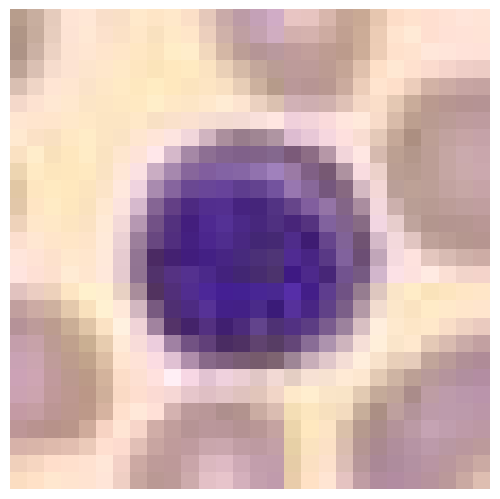

Class 3


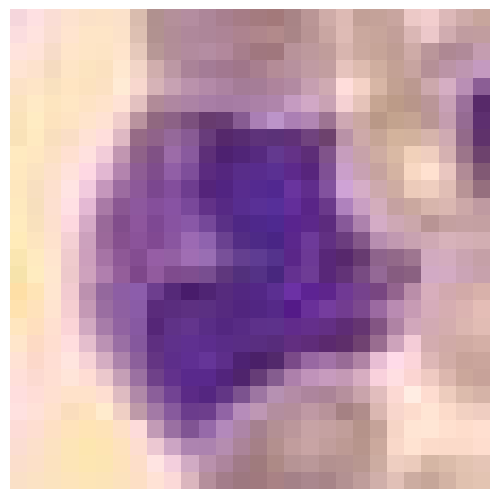

Class 4


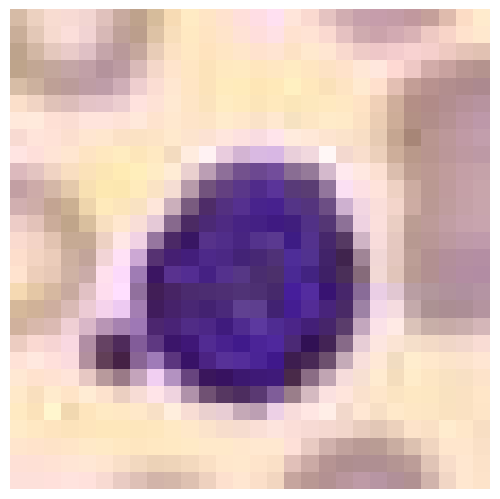

Class 5


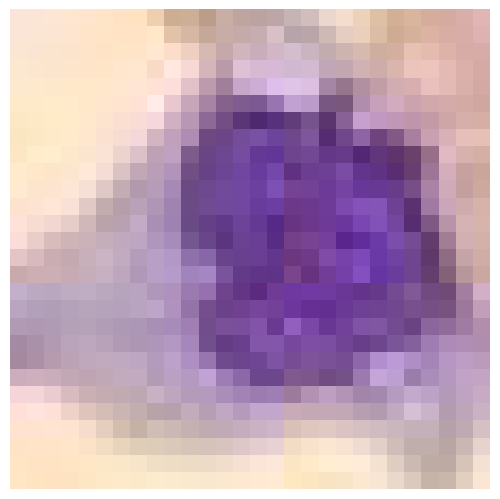

Class 6


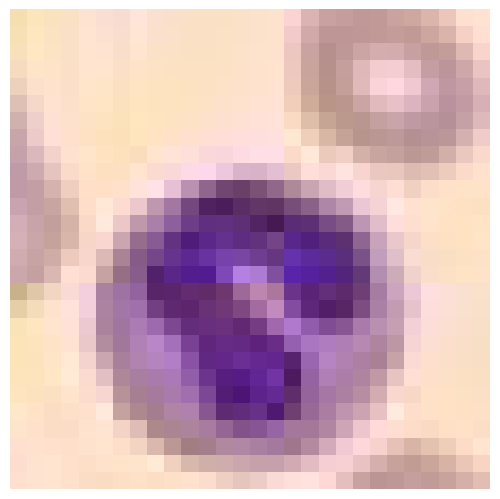

Class 7


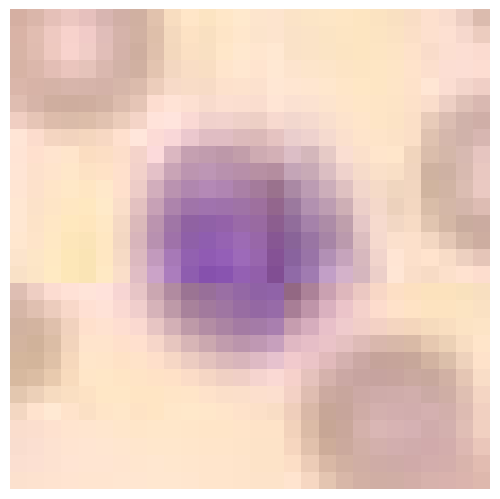

In [4]:
classes = np.unique(Y_train)

def show_image(img):
    fig = plt.figure(frameon=False)
    ax = plt.Axes(fig, [0., 0., 1., 1.])
    ax.set_axis_off()
    fig.add_axes(ax)
    ax.imshow(img)   # RGB image (BloodMNIST)
    plt.show()

print("Displaying 1 example per class:\n")

for cls in classes:
    class_indices = np.where(Y_train == cls)[0]
    selected_idx = np.random.choice(class_indices, 1, replace=False)[0]
    
    print(f"Class {cls}")
    show_image(X_train[selected_idx])

In [19]:
def show_class_distribution(Y, split_name):
    Y = np.asarray(Y)
    assert Y.ndim == 1, f"{split_name} labels must be 1D, got shape {Y.shape}"

    unique, counts = np.unique(Y, return_counts=True)
    print(f"\nClass distribution in {split_name}:")
    for u, c in zip(unique, counts):
        print(f"  {u}: {config.labels[u]} — {c} samples")
    print(f"  Total samples: {counts.sum()}")

    return pd.DataFrame({
        "class_id": unique,
        "label": [config.labels[u] for u in unique],
        "count": counts
    })


def plot_class_histograms_horizontal(train_df, val_df, test_df, save_path=None):
    sns.set_style("whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(13, 5), sharey=True)
    splits = [
        ("Train", train_df),
        ("Validation", val_df),
        ("Test", test_df),
    ]
    for ax, (name, df) in zip(axes, splits):
        sns.barplot(
            data=df,
            x="label",
            y="count",
            ax=ax,
            color="#9b88f2"
        )
        ax.set_title(name)
        ax.set_xlabel("Class")
        ax.set_ylabel("Number of samples")
        ax.tick_params(axis="x", rotation=25)
        ax.set_xticklabels(ax.get_xticklabels(), ha="right")
        for p in ax.patches:
            height = p.get_height()
            ax.annotate(
                f"{int(height)}",
                (p.get_x() + p.get_width() / 2., height),
                ha='center',
                va='bottom',
                fontsize=11
            )
    fig.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, format="svg", bbox_inches="tight")
        print(f"Saved to: {save_path}")
    plt.show()


Class distribution in Train:
  0: Basophil — 852 samples
  1: Eosinophil — 2181 samples
  2: Erythroblast — 1085 samples
  3: Immature granulocyte — 2026 samples
  4: Lymphocyte — 849 samples
  5: Monocyte — 993 samples
  6: Neutrophil — 2330 samples
  7: Platelet — 1643 samples
  Total samples: 11959

Class distribution in Validation:
  0: Basophil — 122 samples
  1: Eosinophil — 312 samples
  2: Erythroblast — 155 samples
  3: Immature granulocyte — 290 samples
  4: Lymphocyte — 122 samples
  5: Monocyte — 143 samples
  6: Neutrophil — 333 samples
  7: Platelet — 235 samples
  Total samples: 1712

Class distribution in Test:
  0: Basophil — 244 samples
  1: Eosinophil — 624 samples
  2: Erythroblast — 311 samples
  3: Immature granulocyte — 579 samples
  4: Lymphocyte — 243 samples
  5: Monocyte — 284 samples
  6: Neutrophil — 666 samples
  7: Platelet — 470 samples
  Total samples: 3421


/tmp/ipykernel_682163/803606834.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_682163/803606834.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_682163/803606834.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


Saved to: blood_mnist_class_distribution.svg


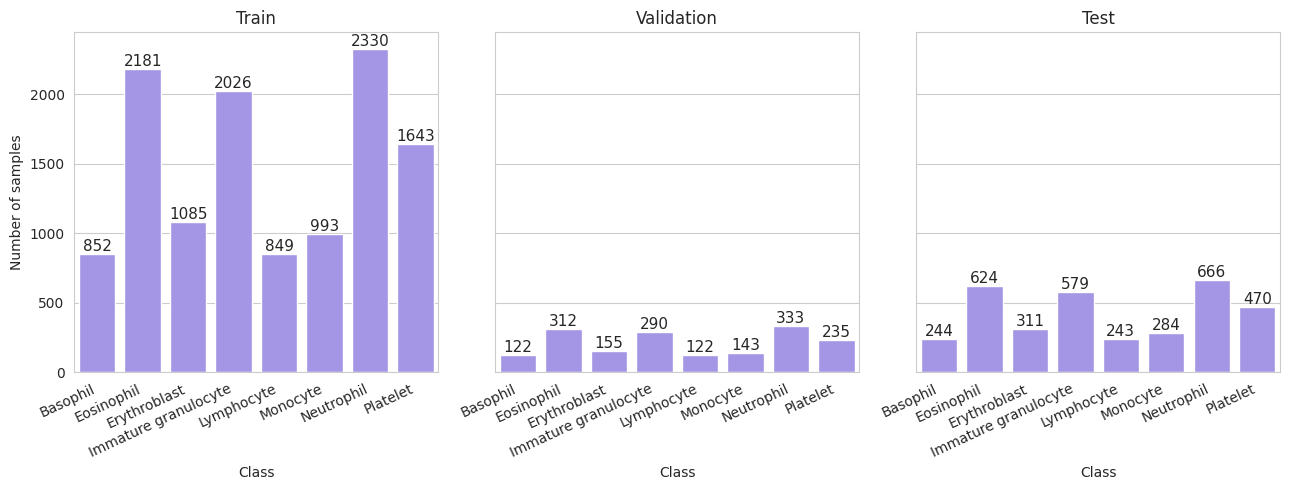

In [21]:
train_counts = show_class_distribution(Y_train, "Train")
val_counts   = show_class_distribution(Y_val, "Validation")
test_counts  = show_class_distribution(Y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts, save_path="blood_mnist_class_distribution.svg")

In [7]:
def horizontal_flip(image):
    return cv2.flip(image, 1)

def vertical_flip(image):
    return cv2.flip(image, 0)

def rotate(image, angle):
    h, w = image.shape[:2]
    center = (w // 2, h // 2)
    matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    return cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

def translate(image, tx, ty):
    h, w = image.shape[:2]
    matrix = np.float32([[1, 0, tx], [0, 1, ty]])
    return cv2.warpAffine(image, matrix, (w, h), borderMode=cv2.BORDER_REFLECT)

def adjust_brightness(image, factor):
    image = image.astype(np.float32)
    image = image * factor
    return np.clip(image, 0, 255).astype(np.uint8)

def adjust_contrast(image, factor):
    mean = np.mean(image, axis=(0, 1), keepdims=True)
    image = image.astype(np.float32)
    image = (image - mean) * factor + mean
    return np.clip(image, 0, 255).astype(np.uint8)

In [8]:
def augment_image(image):
    """
    Data augmentation for BloodMNIST images.
    Applies at most two random, conservative transformations.
    """
    image = image.copy()
    transforms = []

    # --- Geometric transforms ---
    if np.random.rand() < 0.5:
        transforms.append(lambda x: horizontal_flip(x))

    if np.random.rand() < 0.5:
        transforms.append(lambda x: vertical_flip(x))

    if np.random.rand() < 0.4:
        transforms.append(lambda x: rotate(x, np.random.uniform(0, 360)))

    if np.random.rand() < 0.3:
        transforms.append(
            lambda x: translate(
                x,
                np.random.randint(-2, 3),
                np.random.randint(-2, 3),
            )
        )

    # --- Photometric transforms ---
    if np.random.rand() < 0.3:
        transforms.append(lambda x: adjust_brightness(x, np.random.uniform(0.9, 1.1)))

    if np.random.rand() < 0.3:
        transforms.append(lambda x: adjust_contrast(x, np.random.uniform(0.9, 1.1)))

    # --- Apply at most two transforms ---
    np.random.shuffle(transforms)
    for t in transforms[:2]:
        image = t(image)

    return image


In [9]:
import numpy as np

def augment_training_set(
    X_train,
    y_train,
    augment_classes,
):

    X_aug = []
    y_aug = []

    for img, label in zip(X_train, y_train):
        X_aug.append(img)
        y_aug.append(label)

        if label in augment_classes:
            n_aug = augment_classes[label] - 1
            for _ in range(n_aug):
                X_aug.append(augment_image(img))
                y_aug.append(label)

    X_balanced = np.stack(X_aug)
    Y_balanced = np.array(y_aug, dtype=y_train.dtype)

    return X_balanced, Y_balanced


In [10]:
X_balanced, Y_balanced = augment_training_set(X_train, Y_train, config.AUGMENT_CLASSES)

X_train, Y_train = X_balanced, Y_balanced

In [11]:
train_counts = show_class_distribution(Y_balanced, "Train")
val_counts   = show_class_distribution(Y_val, "Validation")
test_counts  = show_class_distribution(Y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts)


Class distribution in Train:
  0: Basophil — 2556 samples
  1: Eosinophil — 2181 samples
  2: Erythroblast — 2170 samples
  3: Immature granulocyte — 2026 samples
  4: Lymphocyte — 2547 samples
  5: Monocyte — 2979 samples
  6: Neutrophil — 2330 samples
  7: Platelet — 3286 samples
  Total samples: 20075

Class distribution in Validation:
  0: Basophil — 122 samples
  1: Eosinophil — 312 samples
  2: Erythroblast — 155 samples
  3: Immature granulocyte — 290 samples
  4: Lymphocyte — 122 samples
  5: Monocyte — 143 samples
  6: Neutrophil — 333 samples
  7: Platelet — 235 samples
  Total samples: 1712

Class distribution in Test:
  0: Basophil — 244 samples
  1: Eosinophil — 624 samples
  2: Erythroblast — 311 samples
  3: Immature granulocyte — 579 samples
  4: Lymphocyte — 243 samples
  5: Monocyte — 284 samples
  6: Neutrophil — 666 samples
  7: Platelet — 470 samples
  Total samples: 3421


/tmp/ipykernel_3945520/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_3945520/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_3945520/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


Error in callback <function flush_figures at 0x7c9ef8f50720> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

In [ ]:
os.makedirs(config.DATA_DIR, exist_ok=True)

In [ ]:
np.save(os.path.join(config.DATA_DIR, "X_train_balanced.npy"), X_train)
np.save(os.path.join(config.DATA_DIR, "Y_train_balanced.npy"), Y_train)

np.save(os.path.join(config.DATA_DIR, "X_test.npy"), X_test)
np.save(os.path.join(config.DATA_DIR, "Y_test.npy"), Y_test)

np.save(os.path.join(config.DATA_DIR, "X_val.npy"), X_val)
np.save(os.path.join(config.DATA_DIR, "Y_val.npy"), Y_val)


In [ ]:
X_train_balanced = np.load(os.path.join(config.DATA_DIR, "X_train_balanced.npy"))
y_train_balanced = np.load(os.path.join(config.DATA_DIR, "Y_train_balanced.npy"))

X_test = np.load(os.path.join(config.DATA_DIR, "X_test.npy"))
y_test = np.load(os.path.join(config.DATA_DIR, "Y_test.npy"))

X_val = np.load(os.path.join(config.DATA_DIR, "X_val.npy"))
y_val = np.load(os.path.join(config.DATA_DIR, "Y_val.npy"))


Class distribution in Train:
  0: Basophil — 2556 samples
  1: Eosinophil — 2181 samples
  2: Erythroblast — 2170 samples
  3: Immature granulocyte — 2026 samples
  4: Lymphocyte — 2547 samples
  5: Monocyte — 2979 samples
  6: Neutrophil — 2330 samples
  7: Platelet — 3286 samples
  Total samples: 20075

Class distribution in Validation:
  0: Basophil — 122 samples
  1: Eosinophil — 312 samples
  2: Erythroblast — 155 samples
  3: Immature granulocyte — 290 samples
  4: Lymphocyte — 122 samples
  5: Monocyte — 143 samples
  6: Neutrophil — 333 samples
  7: Platelet — 235 samples
  Total samples: 1712

Class distribution in Test:
  0: Basophil — 244 samples
  1: Eosinophil — 624 samples
  2: Erythroblast — 311 samples
  3: Immature granulocyte — 579 samples
  4: Lymphocyte — 243 samples
  5: Monocyte — 284 samples
  6: Neutrophil — 666 samples
  7: Platelet — 470 samples
  Total samples: 3421


/tmp/ipykernel_2641691/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_2641691/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")
/tmp/ipykernel_2641691/4034229358.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), ha="right")


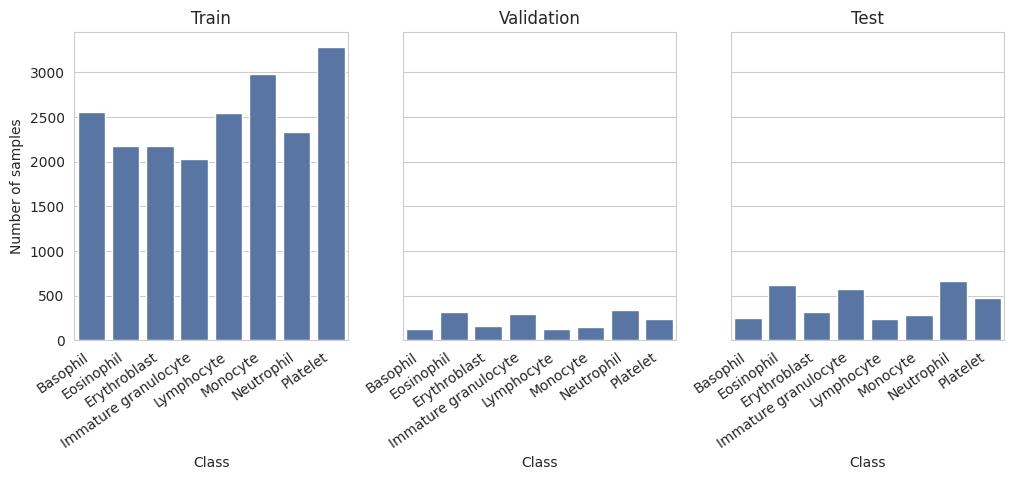

In [ ]:
train_counts = show_class_distribution(y_train_balanced, "Train")
val_counts   = show_class_distribution(y_val, "Validation")
test_counts  = show_class_distribution(y_test, "Test")

plot_class_histograms_horizontal(train_counts, val_counts, test_counts)